# Loyiha 1: Normal Equation va MSE kosasi — Yacht Hydrodynamics (Delft, UCI)

**Talaba:** student_new_2 · **Modul:** M1 (Chiziqli algebra) + M3 1-qism · **Kitob (ML_GUIDE):** 3-bob (Matematik asoslar), 5-bob (Normal Equation vs GD) · **Qiyinlik:** ⭐⭐⭐ · **Taxminiy vaqt:** 5–6 soat · **Muddat:** ____________
> **Qoidalar.** Bu notebook — sizning ish daftaringiz. Har bir `# TODO` katakni to'ldiring, har bir **Savol** ga darhol pastida yangi *markdown* katak ochib 2–5 gap bilan javob bering ("ha/yo'q" baholanmaydi). Topshirishdan oldin `Kernel → Restart & Run All` — notebook yuqoridan pastga **xatosiz** ishlashi shart. Internetdan o'rganish — mumkin va kerak; tayyor kodni nusxalash — yo'q (himoyada har bir qatorni tushuntirib bera olishingiz kerak).

## Loyiha haqida

M1 da Normal Equation ni sun'iy `y = 4 + 3x` ma'lumotda ko'rdingiz. Endi — **haqiqiy** dataset: bir necha feature, shovqin, tuzoqlar. Modelni **faqat NumPy** (`np.linalg`) bilan qurasiz, sklearn faqat javobni tekshirish uchun. Oxirida M3 1-qismdagi **MSE kosasi va contour** ni shu ma'lumot uchun o'zingiz chizasiz.

**Nimani o'rganasiz:** dizayn matritsasi va 1-lar ustuni · θ = (XᵀX)⁻¹Xᵀy · metrikalarni formuladan hisoblash · train/test ni qo'lda ajratish · MSE kosasi qayerda "chuqur" · 🔍 condition number.

**Taqiqlar:** 1–8-vazifalarda modelni o'rgatish uchun `sklearn` ishlatilmaydi (faqat 5-vazifada solishtirish uchun).

## Dataset: Yacht Hydrodynamics (Delft, UCI)

308 ta yaxta korpusi sinovi (Delft universiteti): 5 ta korpus geometriyasi parametri va **Froude soni** (tezlik) → **qoldiq qarshilik** (suvning yaxtaga qarshiligi, birlik og'irlikka). Dengiz muhandisligi: chiziqli model 0.55, lekin **bitta** hiyla 0.99 beradi.

**Manba:** https://archive.ics.uci.edu/ml/machine-learning-databases/00243/yacht_hydrodynamics.data (UCI) — bo'sh joy bilan ajratilgan, sarlavhasiz

| Ustun | Ma'nosi |
|---|---|
| lcb | suzish markazining uzunlamasina holati |
| prismatic | prizmatik koeffitsiyent |
| len_disp | uzunlik / suv siljitish nisbati |
| beam_draught | kenglik / cho'kish nisbati |
| len_beam | uzunlik / kenglik nisbati |
| froude | **Froude soni** — tezlik (0.125 … 0.45, 14 ta qiymat) |
| **resistance** | qoldiq qarshilik — target (0.01 – 62; median 3) |

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00243/yacht_hydrodynamics.data"
cols = ['lcb', 'prismatic', 'len_disp', 'beam_draught', 'len_beam', 'froude', 'resistance']
df = pd.read_csv(url, sep=r'\s+', header=None, names=cols)   # 308 sinov
FEATURES, TARGET = cols[:-1], 'resistance'
print(df.shape); df.head()

(308, 7)


,lcb,prismatic,len_disp,beam_draught,len_beam,froude,resistance
0,-2.3,0.568,4.78,3.99,3.17,0.125,0.11
1,-2.3,0.568,4.78,3.99,3.17,0.150,0.27
2,-2.3,0.568,4.78,3.99,3.17,0.175,0.47
3,-2.3,0.568,4.78,3.99,3.17,0.200,0.78
4,-2.3,0.568,4.78,3.99,3.17,0.225,1.18


## 1-vazifa: Ma'lumot bilan tanishish
`shape`, `describe()`, `isna().sum()`, target histogrammasi, korrelyatsiya jadvali (`df.corr()`), target vs eng kuchli feature scatter.

**Savol 1.** Target taqsimoti simmetrikmi yoki bir tomonga cho'zilganmi? Eng kuchli feature qaysi va bog'lanish to'g'ri chiziqqa o'xshaydimi?

Bu savolda data inspection bajarrdim, shape, describe, null values and correlation heatmap. Missing values yoq, 0 ta chiqdi. Bu yerda eng kuchli korrelatsiya froude va target, resistance chiqdi, 0.82 yani 82% bog'liqlik. Ularning scatter graphdagi ko'rinishi esa exponentional chiqdi, to'g'ri chiqiz emas. Target taqsimoti esa histogrammmada bir tomonga chozilgan, yani right skewed edi. Asosiy qism 0 va 10 orasida joylashgan, qolgan values esa 60 gacha tarqalgan chiqdi.

In [2]:
# TODO: describe, isna, histogram, korrelyatsiya, scatter
print(df.shape)

(308, 7)


In [4]:
df.describe()

,lcb,prismatic,len_disp,beam_draught,len_beam,froude,resistance
count,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000,308.000000
mean,-2.381818,0.564136,4.788636,3.936818,3.206818,0.287500,10.495357
std,1.513219,0.023290,0.253057,0.548193,0.247998,0.100942,15.160490
min,-5.000000,0.530000,4.340000,2.810000,2.730000,0.125000,0.010000
25%,-2.400000,0.546000,4.770000,3.750000,3.150000,0.200000,0.777500
50%,-2.300000,0.565000,4.780000,3.955000,3.150000,0.287500,3.065000
75%,-2.300000,0.574000,5.100000,4.170000,3.510000,0.375000,12.815000
max,0.000000,0.600000,5.140000,5.350000,3.640000,0.450000,62.420000


In [5]:
df.isna().sum() 

lcb             0
prismatic       0
len_disp        0
beam_draught    0
len_beam        0
froude          0
resistance      0
dtype: int64

<Axes: xlabel='resistance', ylabel='Count'>

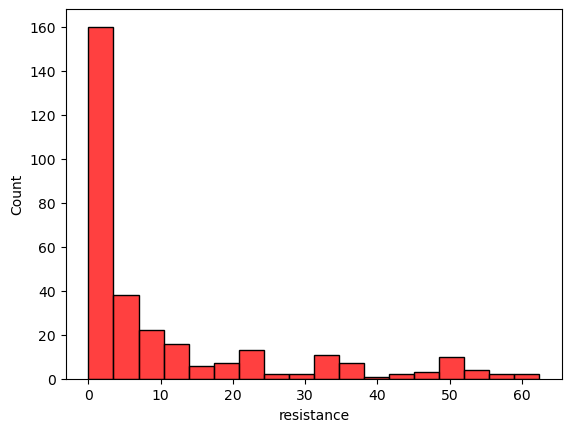

In [6]:
import seaborn as sns
sns.histplot(x="resistance", data=df, color="red")

<Axes: >

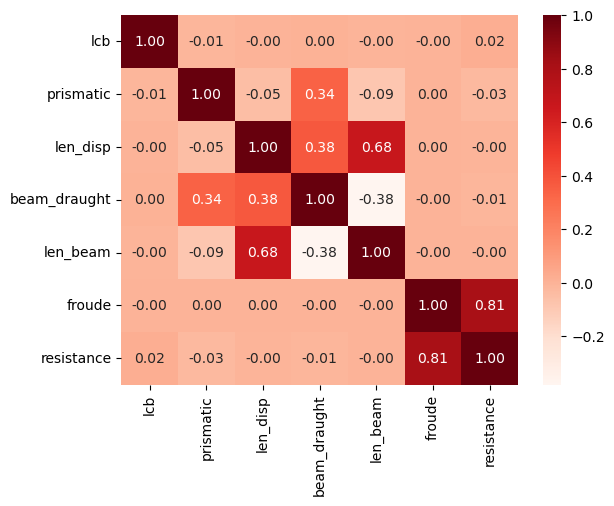

In [11]:
sns.heatmap(df.corr(), annot=True, cmap="Reds", fmt=".2f")

<Axes: xlabel='froude', ylabel='resistance'>

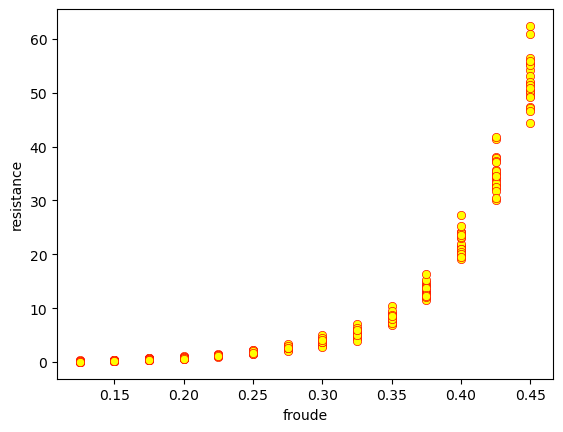

In [13]:
sns.scatterplot(x="froude", y="resistance", data=df, color="yellow", edgecolor="red")

## 2-vazifa: Dizayn matritsasi X va vektor y
`X = np.c_[np.ones(m), ...]` — birinchi ustun bias uchun 1-lar (M1, 5-qism). `X.shape`, `X[:3]` ni chiqaring.

Fayl bo'sh joy bilan ajratilgan, sarlavhasiz — `sep=r'\s+'` va `names` berildi. Missing yo'q. Korrelyatsiya jadvaliga qarang: 5 ta geometriya feature'i va `froude` — qaysilari target bilan bog'liq (1-savol)? Javob sizni hayron qoldirishi mumkin.

**Savol 2.** Nega 1-lar ustuni kerak? Usiz chiziq qayerdan o'tishga majbur bo'ladi?

X_raw ga biz np.c_ orqali birlar ustunini qoshamiz, bundan asosiy maqsadimiz bias ni qoshib ketish. Yani matrix multiplicationda hamma qatorga biasni qoshib ketadi va bu bizda shunday xolatda boladi:
array([[ 1.   , -2.3  ,  0.568,  4.78 ,  3.99 ,  3.17 ,  0.125],
       [ 1.   , -2.3  ,  0.568,  4.78 ,  3.99 ,  3.17 ,  0.15 ],
       [ 1.   , -2.3  ,  0.568,  4.78 ,  3.99 ,  3.17 ,  0.175]])
Biz bu orqali kordinata tekisligi (0;0) nuqtadan otishga majbur bo'lmaymiz, chunki bizni y_interceptimiz bias hisoblanadi, yani y o'qini bias nuqtada kesib o'tadi. Bizni misolda grafigimiz y oqini 1 nuqtaqa kesib o'tadi - (0, 1).

In [18]:
X_raw = df[FEATURES].values; y = df[TARGET].values
l = len(X_raw)
# TODO: X (bias ustuni bilan) va y
X = np.c_[np.ones((l, 1)), X_raw]
X[:3]

array([[ 1.   , -2.3  ,  0.568,  4.78 ,  3.99 ,  3.17 ,  0.125],
       [ 1.   , -2.3  ,  0.568,  4.78 ,  3.99 ,  3.17 ,  0.15 ],
       [ 1.   , -2.3  ,  0.568,  4.78 ,  3.99 ,  3.17 ,  0.175]])

<Axes: >

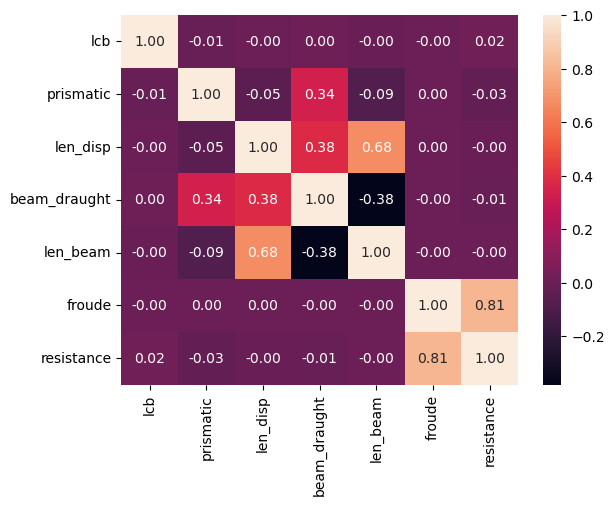

In [19]:
sns.heatmap(df.corr(), annot=True, fmt=".2f")

## 3-vazifa: Normal Equation
Funksiya yozing va θ ni feature nomlari bilan jadval qilib chiqaring (`pd.Series`).

**Savol 3.** Eng katta |θ| qaysi feature'da? Bu "eng muhim feature" degani **emas** — nega? (Maslahat: feature'larning o'lchov birliklari; 3-tadqiqotda qaytamiz.)

Bu yerda eng katta theta froude da, 121.67 chiqdi. Bizda eng katta theta eng muhim feature degani emas, chunki feature importance ni bilishdan oldin biz Scaling qilishimiz kerak. Buni oson misol bilan tushuntiraman. Masalan bir uy narxini hisoblamoqchimiz. Maydoni bittasi 100m^2 bergan ikkinchisi esa 1_000_000 cm^2 bergan, bunda bizning thetamiz har xil chiqadi, so biz birnchi scaling qilib olishimiz kerak shunga qarab feature importanceni aniqlay olamiz.

In [20]:
def normal_equation(X, y):
    """θ = (XᵀX)⁻¹ Xᵀ y"""
    # TODO
    theta = np.linalg.inv(X.T @ X) @ X.T @ y
    return theta

theta = normal_equation(X, y)
# TODO: pd.Series(theta, index=['bias'] + feature_nomlari)
table = pd.Series(theta, index=["bias"] + cols[:-1])
table

bias            -19.236661
lcb               0.193844
prismatic        -6.419376
len_disp          4.232999
beam_draught     -1.765695
len_beam         -4.516432
froude          121.667572
dtype: float64

## 4-vazifa: Metrikalar — formuladan
`y_pred = X @ theta`. MSE, RMSE, MAE va R² = 1 − SS_res/SS_tot ni **o'zingiz** yozing, keyin `sklearn.metrics` bilan `np.isclose` orqali tekshiring.

**Savol 4.** RMSE ni target birligida izohlang ("model o'rtacha … ga adashadi"). R² = 0 va R² = 1 nimani anglatadi?

Bunda custom metrices ni sklearn metrices bilan solishtirdim bir xil chiqdi, yani hamma value togri va teng. RMSE taxminan 8.86 yani modelimizning ortacha adashish xatoligi. 
R2 = 1 bo'lsa bu perfect fit bo'ladi, yani model bexato ishlayapti.
R2 = 0.8 bo'lsa modelimiz 80 % variationni topyapti, 20% error yoki noise.
R2 = 0 bolsa kpi 0 ga teng doim bir xil dummy error beradi.
R2 < 0 model juda yomon hatto meanni ham hisoblay olmaydi

In [26]:
import numpy as np
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

# Predict using calculated theta
y_pred = X @ theta

# Define functions properly by passing both y_true and y_pred
def custom_mse(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def custom_rmse(y_true, y_pred):
    return np.sqrt(custom_mse(y_true, y_pred))

def custom_mae(y_true, y_pred):
    return np.mean(np.abs(y_true - y_pred))

def custom_r2_score(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - np.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

# Calculate metrics using custom functions
res_r2 = custom_r2_score(y, y_pred)
res_rmse = custom_rmse(y, y_pred)
res_mse = custom_mse(y, y_pred)
res_mae = custom_mae(y, y_pred)

print("My Metrics:")
print(f"R2: {res_r2:.4f}, RMSE: {res_rmse:.4f}, MSE: {res_mse:.4f}, MAE: {res_mae:.4f}")

#  scikit-learn metrices
print("\nSklearn Metrics:")
print(f"R2: {r2_score(y, y_pred):.4f}")
print(f"RMSE: {root_mean_squared_error(y, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y, y_pred):.4f}")

# Checking with np.isclose()
print()
print("R2 matches:", np.isclose(my_r2, sk_r2))
print("MSE matches:", np.isclose(my_mse, sk_mse))
print("RMSE matches:", np.isclose(my_rmse, sk_rmse))
print("MAE matches:", np.isclose(my_mae, sk_mae))

My Metrics:
R2: 0.6576, RMSE: 8.8572, MSE: 78.4501, MAE: 7.1603

Sklearn Metrics:
R2: 0.6576
RMSE: 8.8572
MSE: 78.4501
MAE: 7.1603

R2 matches: True
MSE matches: True
RMSE matches: True
MAE matches: True


## 5-vazifa: sklearn bilan solishtirish
`LinearRegression().fit(X[:, 1:], y)` → `coef_`, `intercept_` sizning θ bilan `np.allclose` bo'lishi kerak.

**Savol 5.** 🔍 sklearn `LinearRegression` teskari matritsa (`inv`) ishlatmaydi — hujjatdan qaysi usul (`lstsq` / SVD) ekanini toping va 2 gap bilan yozing (kitob 5-bob).

Men yozgan theta va default sklearn LinReg weightlari hammasi allclose bo'ldi.
Nega LinReg inverse matrix ishlatmaydi:
np.linalg.inv bu judayam sekin, yani computation O(n^3) va juda qimmat va yana multicollinear featurelarni compute qila olmaydi

Instead,
<scipy.linalg.lstsq> yani linear least squares problem, va bu SVD(singular value decomposition) ishlatadi.
Matrix Nolga bo'linib qolmaydi (Matritsa Inversion Insecuritisi yo'q):
Oddiy formulada $(X^T X)^{-1}$ matrix matrisasi teskari olganda, agar 2 ta ustun bir-biriga o'xshash (multicollinear) bo'lsa, xatolik berib dastur ko'chib tushadi (crash bo'ladi).SVD esa diagonal qiymatlardan foydalanadi: nolga teng yoki juda kichik qiymatlarni shunchaki 0 ga tenglashtirib qo'yadi va hech qachon crash bermaydi.
tezkor va havfsiz

In [34]:
# TODO: sklearn LinearRegression bilan solishtirish
print(theta)

[-19.23666079   0.19384434  -6.41937593   4.23299863  -1.76569481
  -4.51643177 121.66757243]


In [29]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X_raw, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [31]:
model.coef_, model.intercept_ 

(array([  0.19384434,  -6.41937593,   4.23299863,  -1.76569481,
         -4.51643177, 121.66757243]),
 np.float64(-19.23666079018887))

In [37]:
sk_weights = np.hstack([model.intercept_, model.coef_])
print(sk_weights)

[-19.23666079   0.19384434  -6.41937593   4.23299863  -1.76569481
  -4.51643177 121.66757243]


In [38]:
print("Bizning thetamiz va sklearn LinearRegression weightlarini solishtiramiz.")
print(np.allclose(theta, sk_weights))

Bizning thetamiz va sklearn LinearRegression weightlarini solishtiramiz.
True


## 6-vazifa: Qo'lda train/test split
`np.random.seed(42); idx = np.random.permutation(m)` → 80% train / 20% test. θ ni faqat train dan toping, R² ni train va test da alohida hisoblang. `seed = 0, 1, 2` bilan takrorlang.

**Savol 6.** Train R² va test R² qanchalik farq qiladi? Test R² seed ga qarab qanchalik "sakraydi" va bu nimani anglatadi (kitob 1-bob: Train/Validation/Test)?

Aksariyat kop hollarda R2 trainda koproq chiqadi, chunki theta trainingdagi malumotlarga qarab optimallashadi. Agar bu ikkisi juda yaqin bolsa generalization juda zor. 

seed ozgarganda R2 ham sakrashi toplamning hajmiga va outlier larga bogliq. 

Bizga nima uchun Cross Validation kerak, chunki bitta split real accuracyni chiqarib bera olmaydi chunki splitimiz lucki bolgan bolishi yoki yomon natija qilgan bolishi mumkin biz mutiple split bilan modelimizning haqiqiy accuracy sini topa olamiz. Va bu step - K-fold Cross-Validation deb ataladi.

In [40]:
# TODO: permutation split, train/test R2, 3 xil seed
np.random.seed(42)
m = X.shape[0]
split = int(m*0.8)
seeds = [0, 1, 2]


for seed in seeds:
    np.random.seed(seed)
    
    idx = np.random.permutation(m)
    
    train_idx = idx[:split]
    test_idx = idx[split:]
    
    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]
    
    theta_tr = np.linalg.inv(X_train.T@X_train)@X_train.T@y_train

    y_train_pred = X_train @ theta_tr
    y_test_pred = X_test @ theta_tr

    r2_test = custom_r2_score(y_train, y_train_pred)
    r2_train = custom_r2_score(y_test, y_test_pred)

    print(f"Seed {seed} -> Train R2: {r2_train:.4f} | Test R2: {r2_test:.4f}")

Seed 0 -> Train R2: 0.6731 | Test R2: 0.6515
Seed 1 -> Train R2: 0.6414 | Test R2: 0.6573
Seed 2 -> Train R2: 0.6427 | Test R2: 0.6591


## 7-vazifa: MSE kosasi va contour (M3 1-qism)
Eng kuchli feature — `froude` (corr ≈ 0.81; qolganlari ≈ 0). Faqat shu bitta feature va bias bilan model: θ₀ va θ₁ uchun to'r (`np.linspace`, 100×100) yasang, har (θ₀, θ₁) uchun MSE ni hisoblang, 3D sirt (`plot_surface`) va contour (`contour`, `levels=30`) chizing. Normal Equation topgan (θ₀, θ₁) ni contour ustida qizil nuqta bilan belgilang.

**Savol 7.** Kosa aylanasimon yoki cho'zilgan ellips shaklidami? Nega (feature masshtabi)? Qizil nuqta haqiqatan eng chuqur joydami — to'rdagi eng kichik MSE bilan solishtiring.

Cho'zilgan ellips shaklida.

Ha, qizil nuqta (Normal Equation yechimi) eng chuqur joyda joylashadi.Solishtirish sababi:Normal Equation ($\theta = (X^TX)^{-1}X^Ty$) analitik yechim bo'lib, hosilani nolga tenglashtirish orqali matematik jihatdan eng absolut kichik MSE beradigan aniq nuqtani topadi.

In [70]:
theta

array([-19.23666079,   0.19384434,  -6.41937593,   4.23299863,
        -1.76569481,  -4.51643177, 121.66757243])

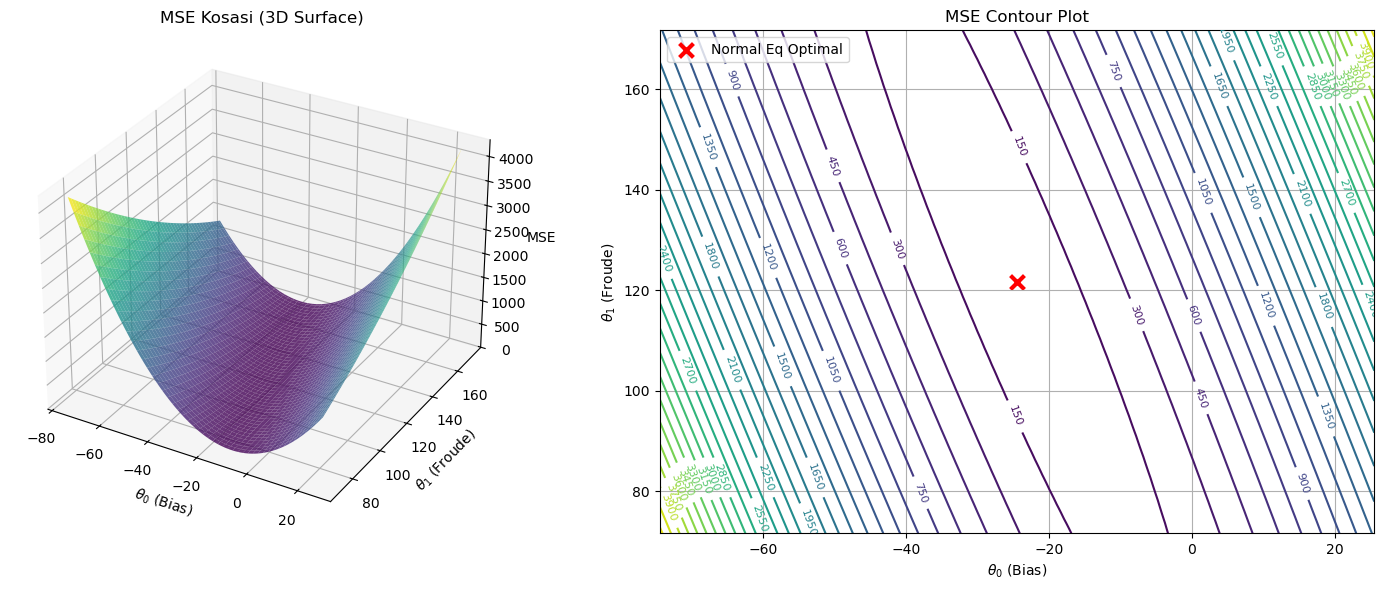

Normal Eq bilan topilgan Optimal MSE: 78.7513
Grid (To'r) dagi eng kichik MSE: 78.7794


In [74]:
froude = df.froude.values.reshape(-1, 1)
m = len(froude)

X_sub = np.c_[np.ones((m, 1)), froude]

theta_opt = np.linalg.inv(X_sub.T@X_sub)@X_sub.T@y

theta0_vals = np.linspace(theta_opt[0]-50, theta_opt[0]+50, 100)
theta1_vals = np.linspace(theta_opt[1]-50, theta_opt[1]+50, 100)

# 2D
T0, T1 = np.meshgrid(theta0_vals, theta1_vals)

# Loss qiymatlarini saqlash uchun nol matritsa
J_vals = np.zeros(T0.shape)
# Har bir grid nuqtasi bo'ylab sikl
for i in range(T0.shape[0]):
    for j in range(T0.shape[1]):
        t = np.array([T0[i, j], T1[i, j]])
        predictions = X_sub @ t
        J_vals[i, j] = np.mean((predictions - y) ** 2)

# To'rdagi eng kichik MSE
min_mse_grid = np.min(J_vals)
# --- GRAFIKLARNI CHIZISH ---
fig = plt.figure(figsize=(15, 6))

# 3D Surface plot
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
surf = ax1.plot_surface(T0, T1, J_vals, cmap='viridis', alpha=0.8)
ax1.set_xlabel(r'$\theta_0$ (Bias)')
ax1.set_ylabel(r'$\theta_1$ (Froude)')
ax1.set_zlabel('MSE')
ax1.set_title('MSE Kosasi (3D Surface)')

# 2D Contour plot
ax2 = fig.add_subplot(1, 2, 2)
contours = ax2.contour(T0, T1, J_vals, levels=30, cmap='viridis')
plt.clabel(contours, inline=True, fontsize=8)

# Normal Equation nuqtasini qizil bilan belgilash
ax2.scatter(theta0_opt, theta1_opt, color='red', marker='x', s=100, linewidths=3, label='Normal Eq Optimal')
ax2.set_xlabel(r'$\theta_0$ (Bias)')
ax2.set_ylabel(r'$\theta_1$ (Froude)')
ax2.set_title('MSE Contour Plot')
ax2.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print(f"Normal Eq bilan topilgan Optimal MSE: {np.mean((X_sub @ theta_opt - y) ** 2):.4f}")
print(f"Grid (To'r) dagi eng kichik MSE: {min_mse_grid:.4f}")

## 8-vazifa: Dataset tuzog'i
**Fizika yordami.** Scatter `froude` vs `resistance`: to'g'ri chiziq emas — eksponensial o'sish (qarshilik ~ tezlik⁴…⁶). Target ni `np.log(resistance)` ga almashtirib Normal Equation ni qayta yeching, bashoratni `np.exp` bilan qaytaring: R² 0.55 dan qanchaga o'sdi? Endi 5 ta geometriya feature'i ham "ishlay boshladi"mi (θ larga qarang)? Nega log target chiziqli modelni "ko'paytma" modelga aylantiradi (log(a·b) = log a + log b)?

[0.012, -0.393, 0.479, -0.077, -0.489, 18.002] va bias = -4.2615 transformatsiyadan keyin judayam ozgarib ketdi valuelar. froude qiymati 18 ga tushdi va qolgan columnlar ham kotarildi. Eng qizigi R2 65 dan 98 ga kotarilib ketdi.

np.log degani asida base-e ostidagi logarifmik hisoblash degani:
$$\ln(y) = \theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n$$
keyin esa
$$e^{\ln(y)} = e^{(\theta_0 + \theta_1 x_1 + \theta_2 x_2 + \dots + \theta_n x_n)}$$
Algebraga ko'ra, darajalarning yig'indisi ularning ko'paytmasiga teng 
($e^{a+b} = e^a \cdot e^b$):$$y = e^{\theta_0} \cdot e^{\theta_1 x_1} \cdot e^{\theta_2 x_2} \cdot \dots \cdot e^{\theta_n x_n}$$
Ko'rib turganingizdek, o'ng tarafdagi barcha qo'shiluvchi qismlar bir-biriga ko'paytma (multiplicative) bo'lib o'tdi.

<Axes: xlabel='froude', ylabel='resistance'>

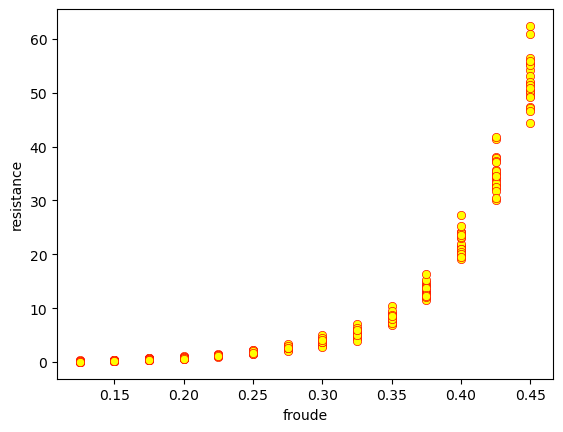

In [44]:
# TODO: dataset-specific tekshiruv
sns.scatterplot(x="froude", y="resistance", data=df, edgecolor="red", color="yellow")

In [45]:
features = cols[:-1]
target = cols[-1]
features, target

(['lcb', 'prismatic', 'len_disp', 'beam_draught', 'len_beam', 'froude'],
 'resistance')

In [52]:
# 1. Target'ni logarifmlaymiz
y_train_log = np.log(y_train)

# 2. Theta'ni log-target bilan hisoblaymiz (pinv xavfsizroq)
theta_log = np.linalg.inv(X_train.T@X_train)@X_train.T @ y_train_log

# 3. Test set'da bashorat olamiz (log miqyosida)
y_pred_log = X_test @ theta_log

# 4. Exponenta orqali asl miqyosga qaytaramiz
y_pred_exp = np.exp(y_pred_log)

# 5. R2 ni hisoblaymiz (asl y_test va exp qaytarilgan bashorat o'rtasida)
r2_after_log = custom_r2_score(y_test, y_pred_exp)

print("Log transformation'dan keyingi Test R2:", r2_after_log)

Log transformation'dan keyingi Test R2: 0.9826488058911514


In [53]:
theta_log

array([-4.26157844e+00,  1.21793115e-02, -3.93586754e-01,  4.79106372e-01,
       -7.73288321e-02, -4.89923962e-01,  1.80028009e+01])

## 🔍 Tadqiqot (majburiy — kamida 2 tasi)
1. θ ni 4 usulda toping: `np.linalg.inv`, `np.linalg.solve`, `np.linalg.pinv`, `np.linalg.lstsq`. `%timeit` bilan vaqtini o'lchang. Nega amalda `inv` **tavsiya qilinmaydi**?
2. **Condition number.** `np.linalg.cond(X.T @ X)` ni hisoblang. "Ill-conditioned matrix" nima — 3 gap, o'z so'zingiz bilan. Feature'larni `(x − mean) / std` bilan standartlashtirib qayta hisoblang: cond necha marta kamaydi?
3. **Scaling va θ.** Standartlashtirilgan X bilan Normal Equation ni qayta yeching: bashoratlar o'zgarmadi (`np.allclose`), θ o'zgardi — nega? Endi qaysi θ ni "feature muhimligi" sifatida solishtirish mumkin (3-savolga qayting)? 7-vazifadagi kosa endi qanday shaklda?
4. Faqat `froude` bilan: (a) chiziqli, (b) `froude`, `froude²`, `froude³` ustunlari (qo'lda `np.c_`), (c) log target — uchala R² ni solishtiring. Kitob 4-bob "Linear regression is linear in the parameters, not the features" — bu gapni (b) misolida tushuntiring. Qaysi variant muhandis uchun tushunarli?


## Conclusions
1. Mana isbot nega LinearRegression inverse matrix ishlatmaydi chunki u eng sekin ishlayd va shuning uchun SVD - singular value decomposition ishlatadi u eng tez ishlaydigani ekan.

2. Shartlilik soni $631,000+$ marta kamaydi.Matritsa o'ta yomon shartlangan (ill-conditioned, $cond \approx 633k$) holatdan ideal shartlangan ($cond = 1.00$) holatga o'tdi.

3. Malumotlarning matematik va geometrik  strukturasi ozgarmagani uchun bashoratlar ozgarmaydi, lekin ular scale qilinganda valular qanndaydur miqdorqa ozgaradi shu sababli theta ham ozgaradi



In [82]:
# TODO: tadqiqot
# 1
print("np.linalg.inv")
%timeit np.linalg.inv(X.T@X)@X.T@y
print("np.linalg.solve")
%timeit np.linalg.solve(X.T @ X, X.T @ y)
print("np.linalg.pinv")
%timeit np.linalg.pinv(X) @ y
print("np.linalg.lstsq")
%timeit np.linalg.lstsq(X, y, rcond=None)

np.linalg.inv
181 μs ± 18.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
np.linalg.solve
139 μs ± 20.6 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
np.linalg.pinv
144 μs ± 10.7 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)
np.linalg.lstsq
78.4 μs ± 4.25 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)


In [85]:
# 2 
print(round(np.linalg.cond(X.T@X), 2))

# with froude feature 
froude_scaled = (df.froude.values - df.froude.mean()) / df.froude.std()
X_scaled = np.c_[np.ones((len(froude_scaled), 1)), froude_scaled]
cond_after = np.linalg.cond(X_scaled.T @ X_scaled)
print(f"Standartlashtirishdan keyin cond: {cond_after:.2f}")
print(f"Kamayish nisbati: {633070.88 / cond_after:.2f} marta")

633070.88
Standartlashtirishdan keyin cond: 1.00
Kamayish nisbati: 631015.46 marta


## ⭐ Bonus (+10)
Bitta feature uchun yopiq formula: θ₁ = Σ(x−x̄)(y−ȳ) / Σ(x−x̄)², θ₀ = ȳ − θ₁x̄. Uni 7-vazifadagi feature uchun hisoblang va Normal Equation natijasi bilan solishtiring — bir xilmi? Bu formula Normal Equation ning n = 1 holati ekanini 3–4 qator bilan ko'rsating.

In [78]:
x = froude.ravel() # 1D ko'rinishga keltiramiz
x_bar = np.mean(x)
y_bar = np.mean(y)

# Formulani hisoblaymiz
theta1_closed = np.sum((x - x_bar) * (y - y_bar)) / np.sum((x - x_bar)**2)
theta0_closed = y_bar - theta1_closed * x_bar

print(f"Yopiq formula: theta0 = {theta0_closed:.6f}, theta1 = {theta1_closed:.6f}")

Yopiq formula: theta0 = -24.484070, theta1 = 121.667572


## Topshirish

- Fayl nomi: `student_new_2_J1.ipynb` (shu fayl, to'ldirilgan). `Restart & Run All` qilingan, barcha grafiklar ko'rinib turibdi.
- Oxirgi katak — **Xulosa** (markdown, 6–10 gap): nimani o'rgandingiz, qaysi natija kutilmagan bo'ldi, nimani hali tushunmadingiz.
- Himoya: 5 daqiqa — istalgan katakdagi kodni tushuntirib berasiz.

## Baholash (100 ball + bonus)

| Mezon | Ball |
|---|---|
| 1–8 vazifalar to'liq va to'g'ri | 45 |
| Savollarga tahliliy javoblar (7 ta) | 20 |
| Tadqiqot (2 ta) | 15 |
| Kod tozaligi: funksiyalar, xatosiz Run All | 10 |
| Grafiklar (sarlavha, o'qlar, izoh) | 10 |
| ⭐ Bonus | +10 |

# Conclusions.
Men bu vazifani qilish uchun ancha vaqtim ketdi va bu bu ketgan vaqt davomida Normal Equationni juda chuqur o'rgandim va juda ko'p narsalar yangilik bo'ldi.
Men faqatgina fit() and predict() qilmasdan, under the hood qanday ishlashini grafiklar orqali vizual kordim.

Organgan hulosalarim:
Biz feature importanceni scale qilmasdan turib aniqlashimiz notogri ekan chunki, scale qilganda bir xil format va oraliqqa kelib tushadi, shunda tanlash oqilona boladi
SKlearn Logistic Regression linalg.inv ishlatmaydi chunki u juda sekin Big O notataion n^3 boladi bu esa computationally very expensive va inverse matrix multicollinearityda crash boladi shuning uchun u SVD linalg.lstsq ishlatadi.
Agar np.log va np.exp ishlatilsa bunda base-e logarifmik boladi bunda esa, biz exponentional xolatdan linear holatga otib olamiz, buni ham qisman scaling deb atasak boladi va bubizga accuracy imizni oshirishimzda juda kop yordam beradi.

Tushunmadim:
3D va contour grafigini chizishda ozgina qiynaldi AI dan yordam oldim, this is feeling like little abstract, lekin kodini ozim yozdim.